In [1]:
#extract best seed
import pandas as pd
import glob
import os

# folder containing the 27 seed-metric csv files
folder = "outputs/seed_metrics/Ensemble1"   # change if needed

best_rows = []

for file in glob.glob(os.path.join(folder, "*.csv")):

    df = pd.read_csv(file)

    # pick row with minimum RMSE
    best = df.loc[df["RMSE"].idxmin()]

    best_rows.append(best)

# combine 27 best rows
best_df = pd.DataFrame(best_rows)

# optional sort
best_df = best_df.sort_values(
    ["model","target","stability"]
).reset_index(drop=True)

# save Excel file
best_df.to_excel("best_seeds_summary.xlsx", index=False)

print("Saved best_seeds_summary.xlsx")
print(best_df)

Saved best_seeds_summary.xlsx
   model target stability  seed       RMSE        MAE        R2  Correlation
0    ANN      H       all   105  50.442825  36.080555  0.842573     0.920255
1    ANN      H    stable   460  25.453200  19.206623  0.046758     0.359879
2    ANN      H  unstable   255  61.258906  48.231718  0.523874     0.732354
3    ANN      L       all   145  72.395684  48.952834  0.602881     0.790931
4    ANN      L    stable   230  57.559338  33.691653  0.148411     0.424499
5    ANN      L  unstable    10  80.490089  56.843002  0.423976     0.664894
6    ANN    TAU       all   295   0.199081   0.114930  0.289056     0.601136
7    ANN    TAU    stable   115   0.168251   0.091574  0.098275     0.448445
8    ANN    TAU  unstable    85   0.189317   0.135127  0.332886     0.618682
9     RF      H       all   215  49.265171  35.220661  0.849838     0.924436
10    RF      H    stable   330  25.456998  19.157333  0.057168     0.395742
11    RF      H  unstable   260  60.975990  48

In [3]:
import os
import shutil
import pandas as pd

best = pd.read_excel("best_seeds_summary.xlsx")

src_dir = "saved_models/params"
dst_dir = os.path.join(src_dir, "best_params")

os.makedirs(dst_dir, exist_ok=True)

copied = 0

for _, row in best.iterrows():

    fname = (
        f"{row['model']}_"
        f"{row['target']}_"
        f"{row['stability']}_"
        f"seed{int(row['seed'])}.pkl"
    )

    src = os.path.join(src_dir, fname)
    dst = os.path.join(dst_dir, fname)

    if os.path.exists(src):
        shutil.copy2(src, dst)
        print("Copied:", fname)
        copied += 1
    else:
        print("Missing:", fname)

print(f"\nCopied {copied} files into {dst_dir}")

Copied: ANN_H_all_seed105.pkl
Copied: ANN_H_stable_seed460.pkl
Copied: ANN_H_unstable_seed255.pkl
Copied: ANN_L_all_seed145.pkl
Copied: ANN_L_stable_seed230.pkl
Copied: ANN_L_unstable_seed10.pkl
Copied: ANN_TAU_all_seed295.pkl
Copied: ANN_TAU_stable_seed115.pkl
Copied: ANN_TAU_unstable_seed85.pkl
Copied: RF_H_all_seed215.pkl
Copied: RF_H_stable_seed330.pkl
Copied: RF_H_unstable_seed260.pkl
Copied: RF_L_all_seed215.pkl
Copied: RF_L_stable_seed60.pkl
Copied: RF_L_unstable_seed170.pkl
Copied: RF_TAU_all_seed430.pkl
Copied: RF_TAU_stable_seed250.pkl
Copied: RF_TAU_unstable_seed215.pkl
Copied: XGB_H_all_seed475.pkl
Copied: XGB_H_stable_seed345.pkl
Copied: XGB_H_unstable_seed195.pkl
Copied: XGB_L_all_seed40.pkl
Copied: XGB_L_stable_seed25.pkl
Copied: XGB_L_unstable_seed410.pkl
Copied: XGB_TAU_all_seed85.pkl
Copied: XGB_TAU_stable_seed5.pkl
Copied: XGB_TAU_unstable_seed480.pkl

Copied 27 files into saved_models/params/best_params


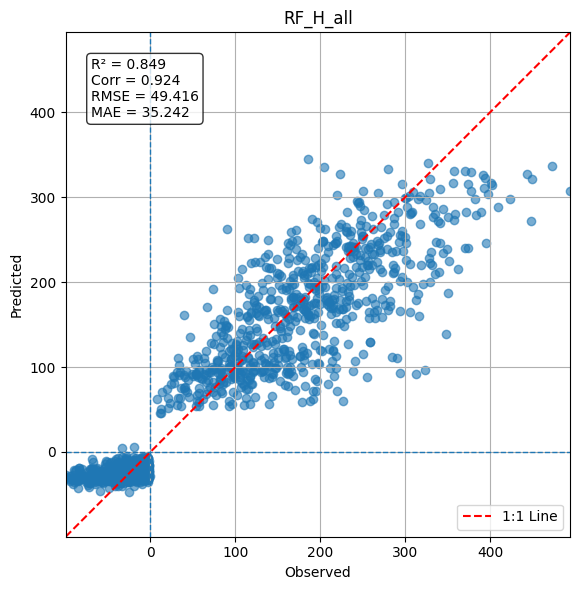

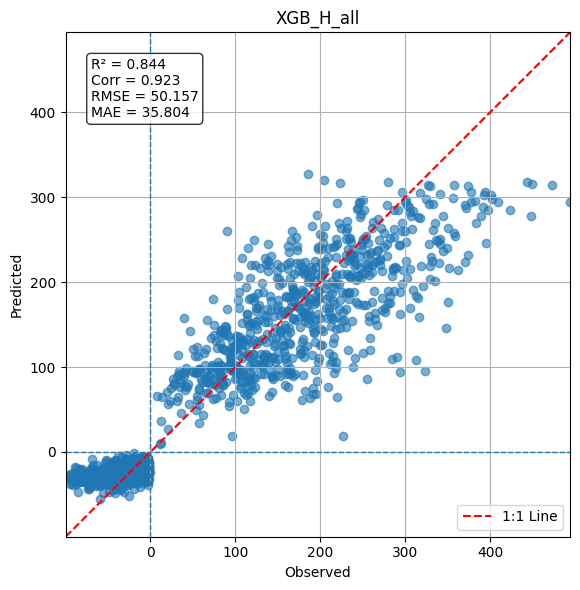

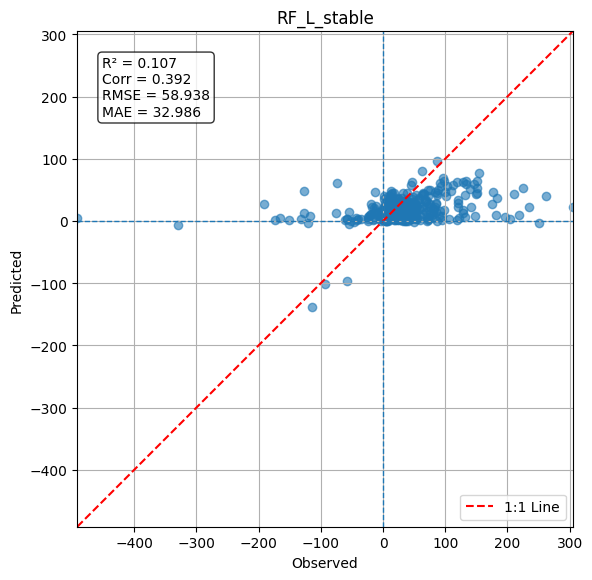

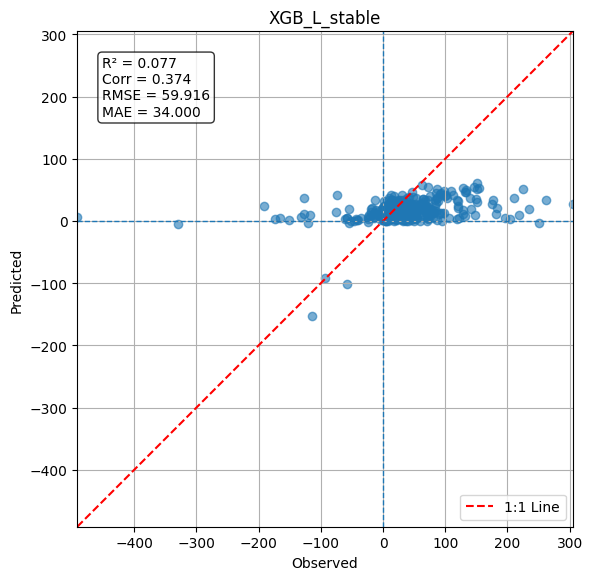

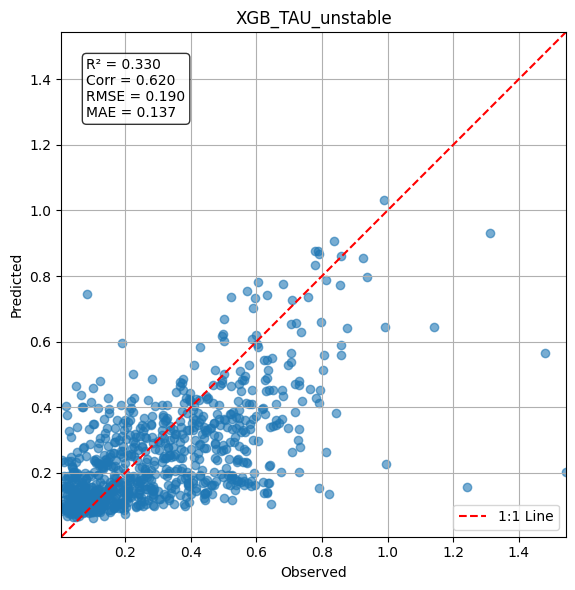

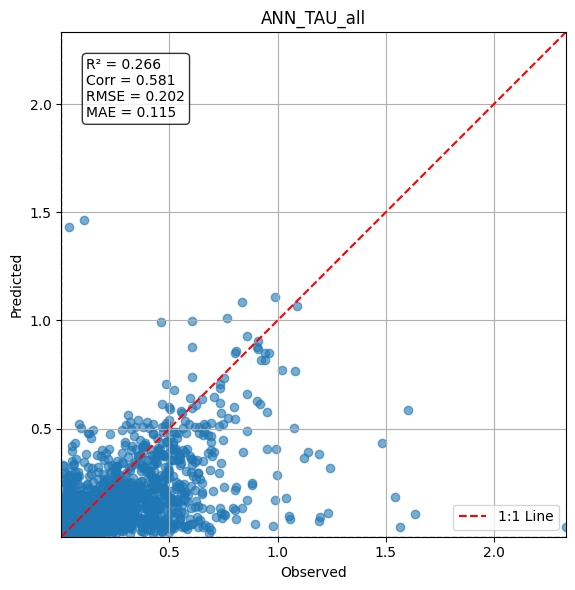

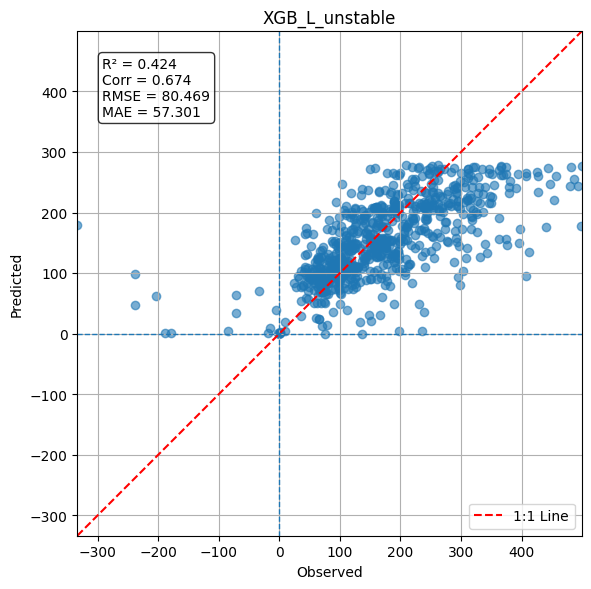

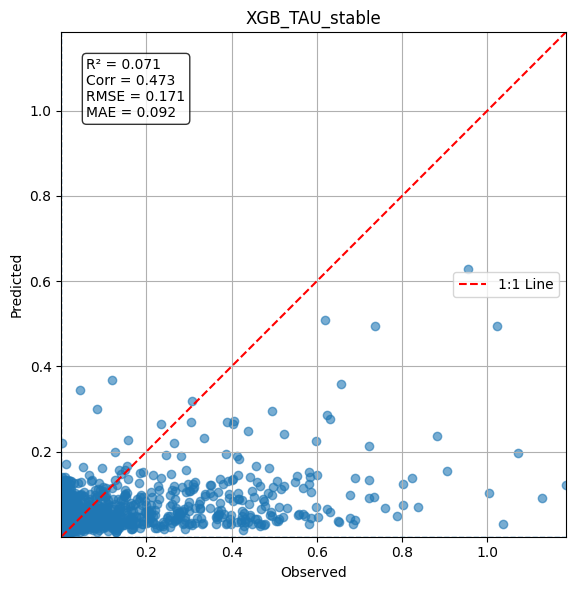

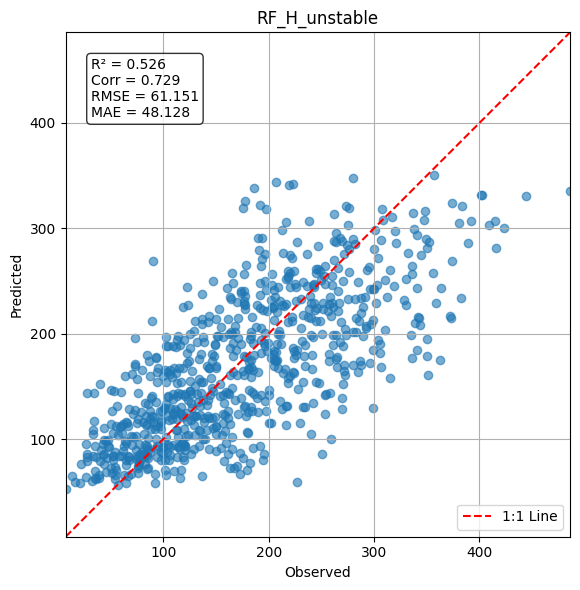

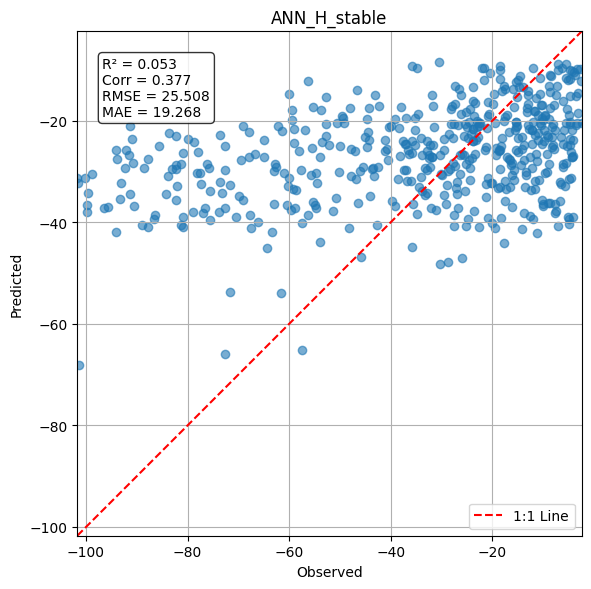

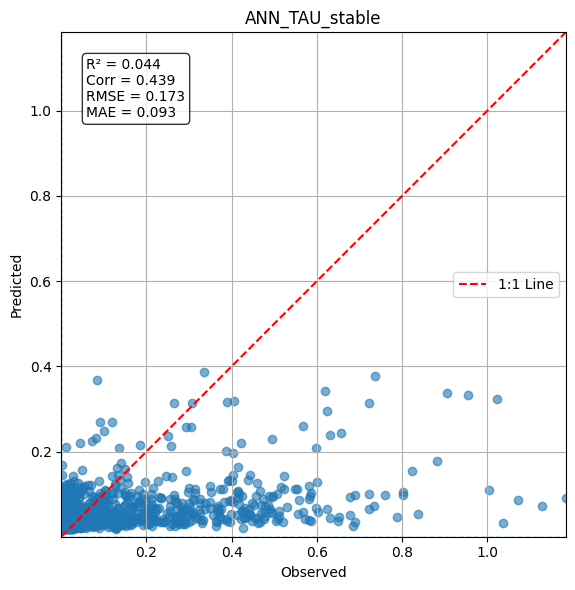

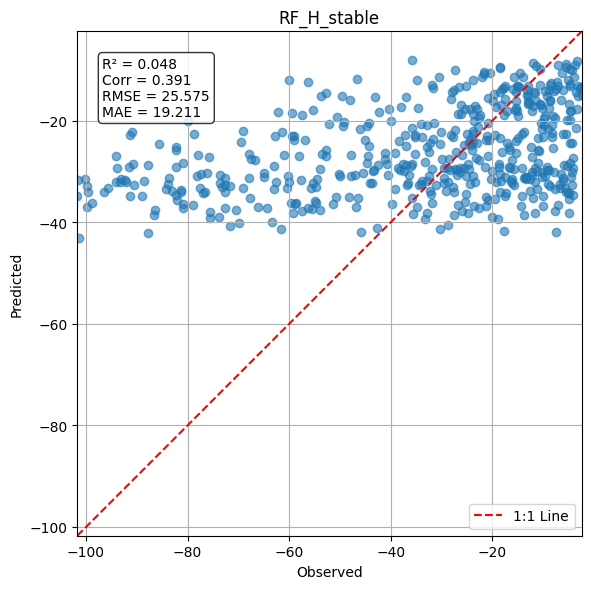

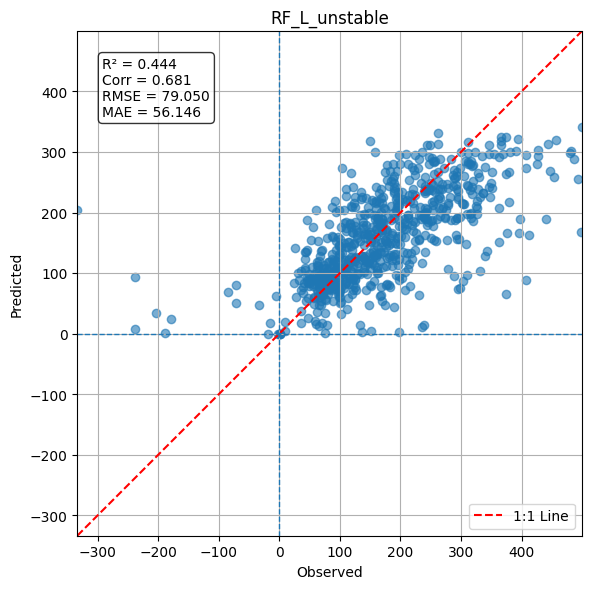

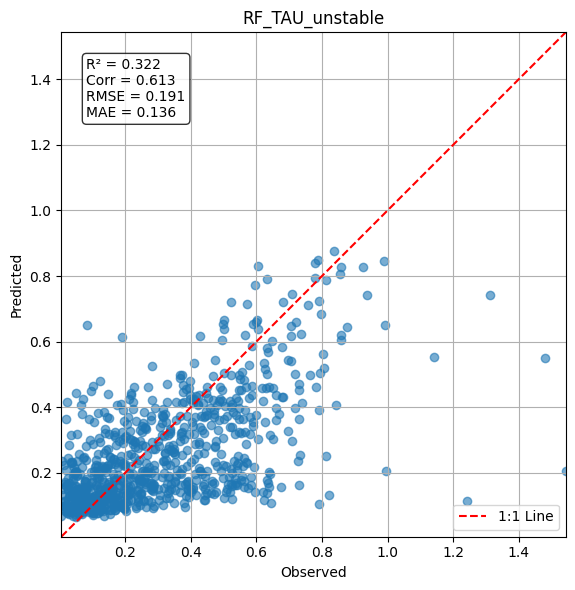

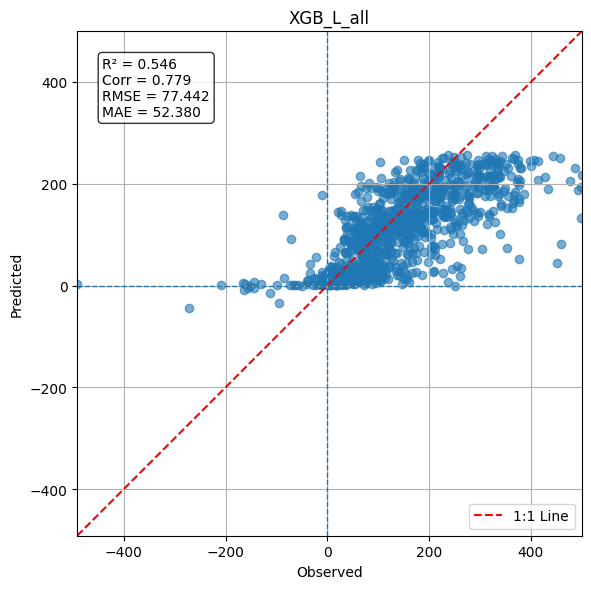

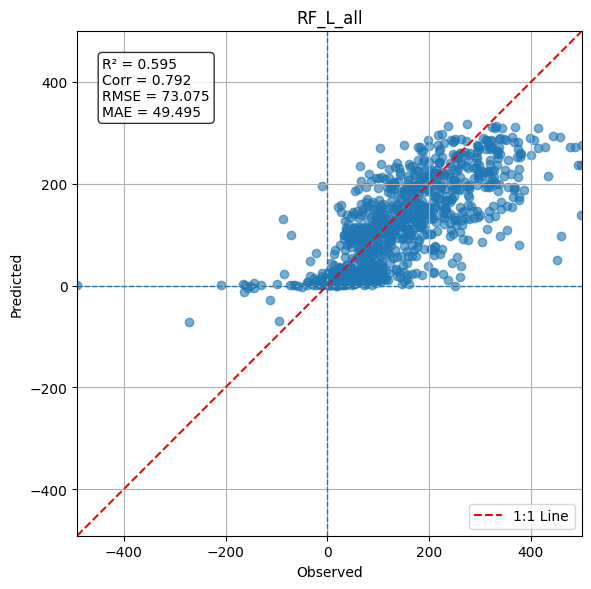

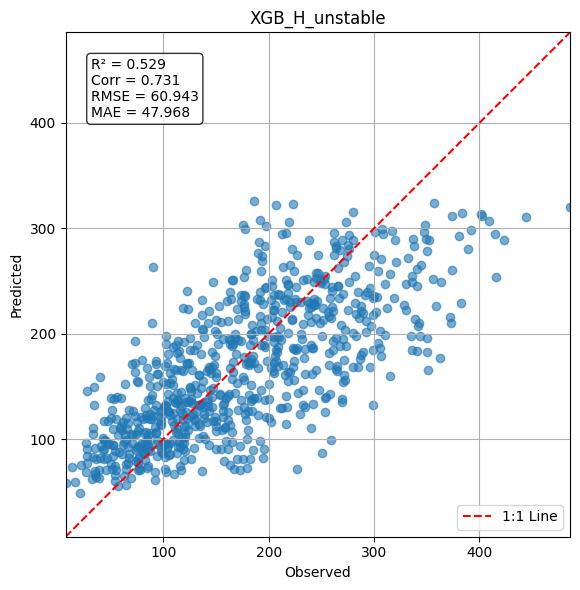

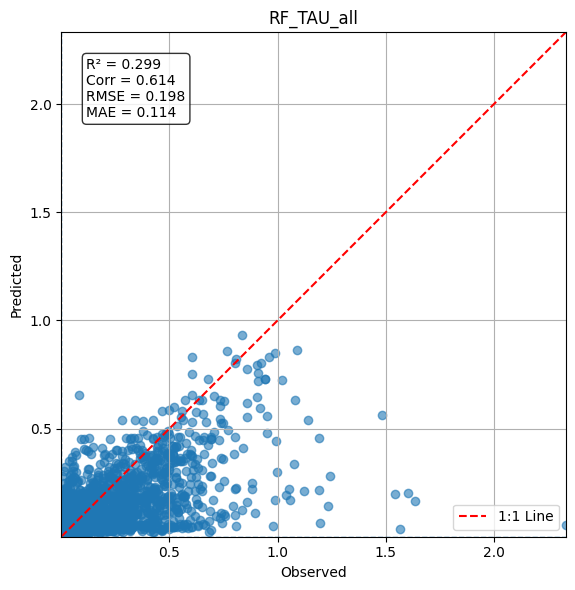

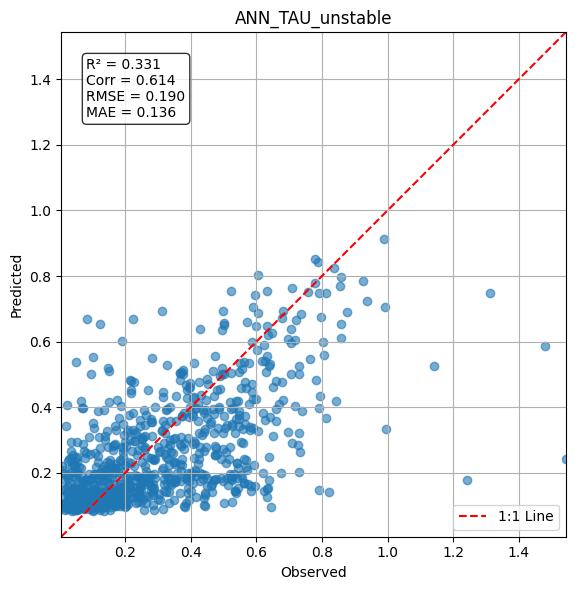

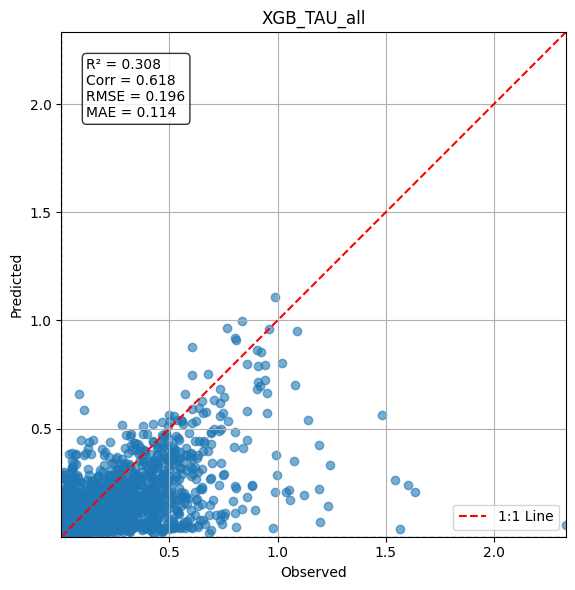

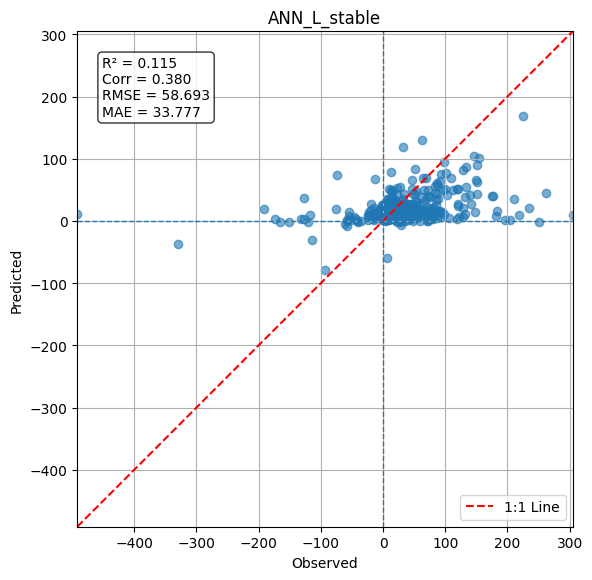

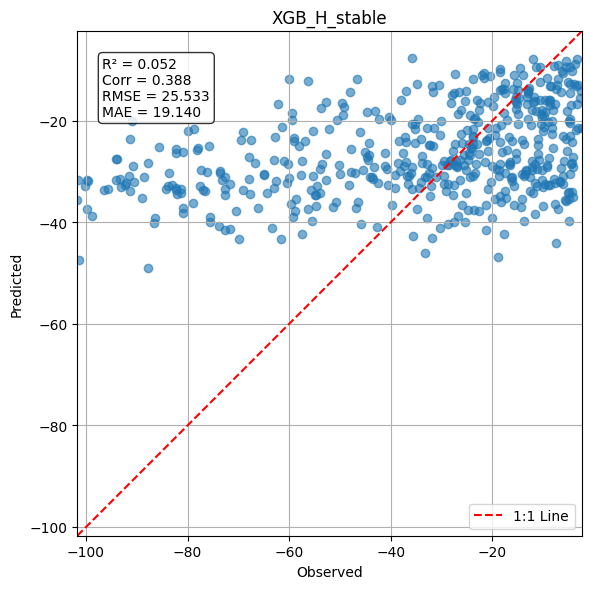

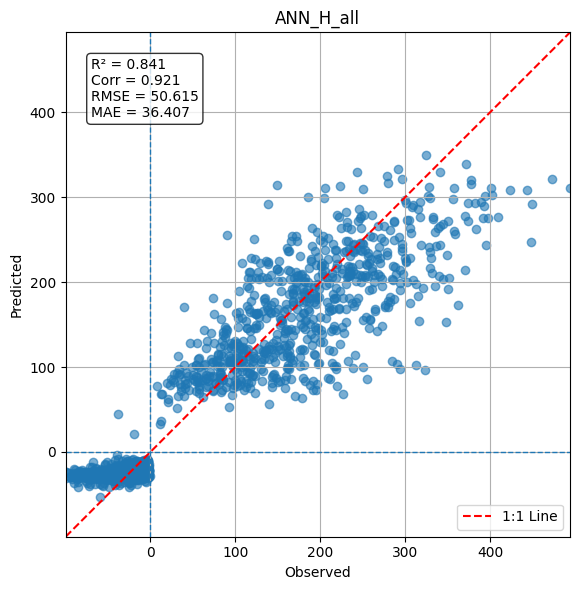

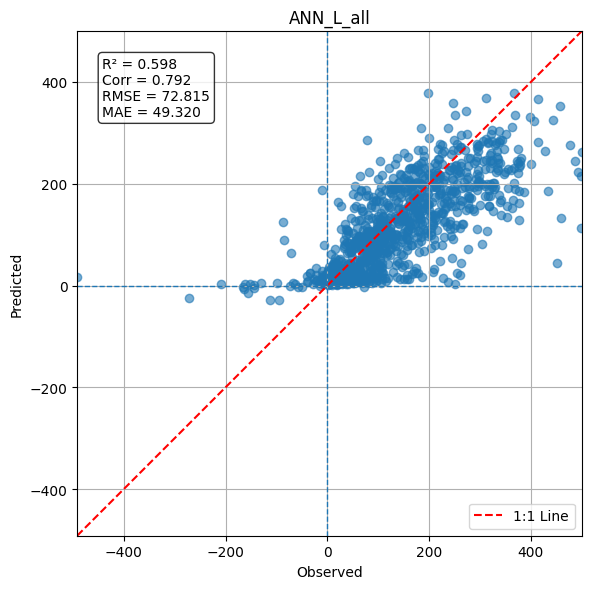

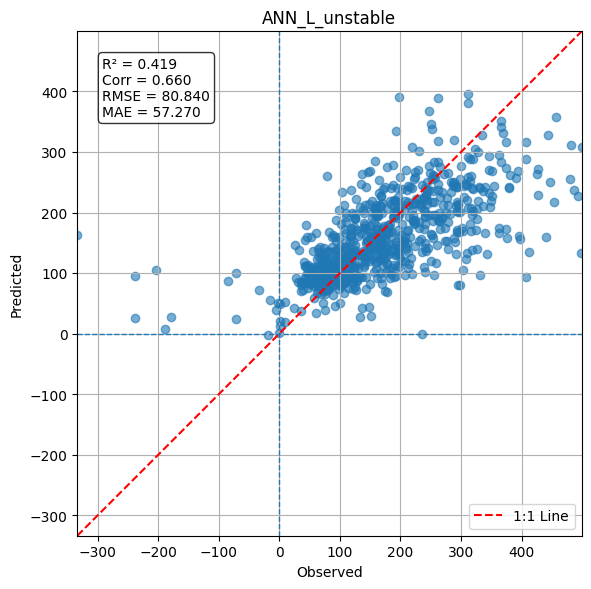

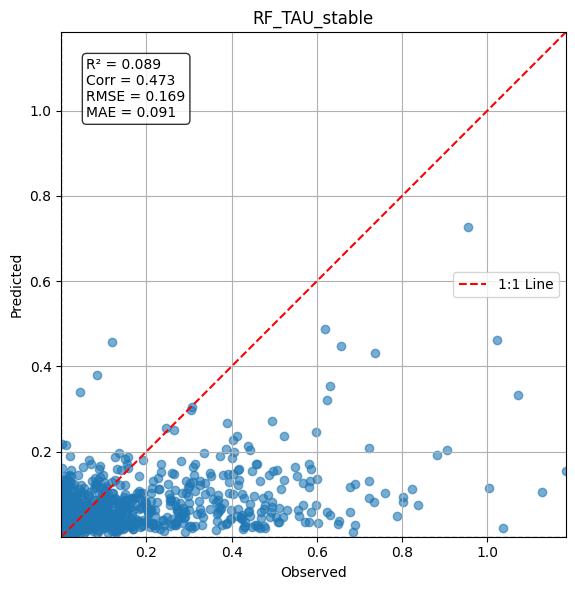

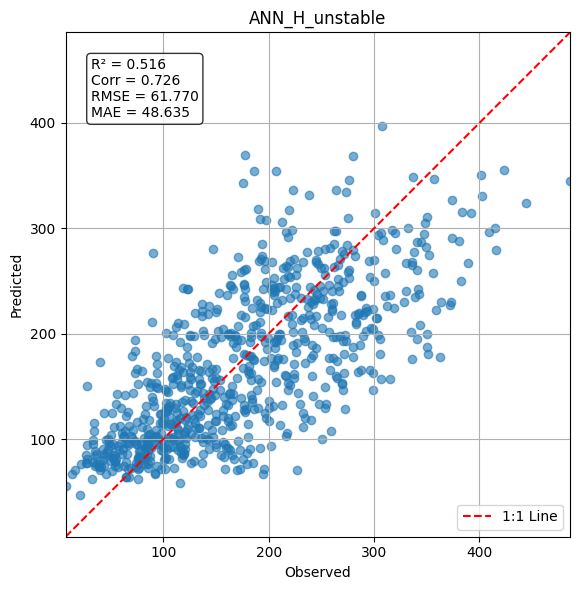

In [1]:
import pandas as pd
import numpy as np
import glob
import os
from utils.plotting import results_plot
from config import get_config

base_path = "outputs/ensemble_preds/Ensemble1"
files = glob.glob(f"{base_path}/*.csv")

H_vals = []
TAU_vals = []

for f in files:
    filename = os.path.basename(f)

    df = pd.read_csv(f)

    y_true = df["y_true"].values
    y_pred = df["y_pred"].values
    model, target, stability = os.path.basename(f).replace(".csv", "").split("_")
    config = get_config( model=model, target=target, stability=stability, mode="predict" )
    results_plot(y_pred, y_true, config)

Plotting: RF L


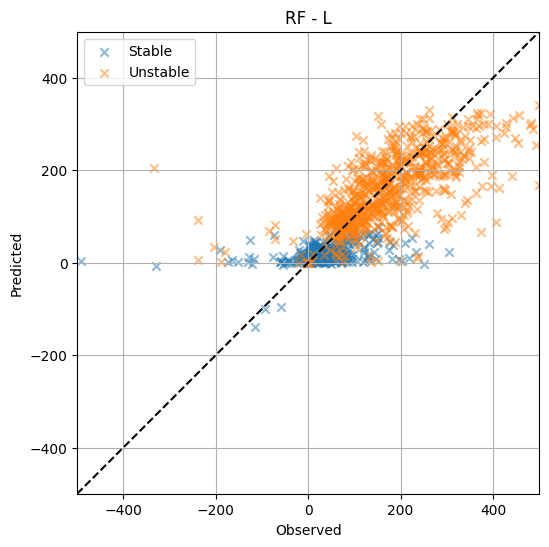

Saved: outputs/combined_plots/RF_L.svg
Plotting: XGB L


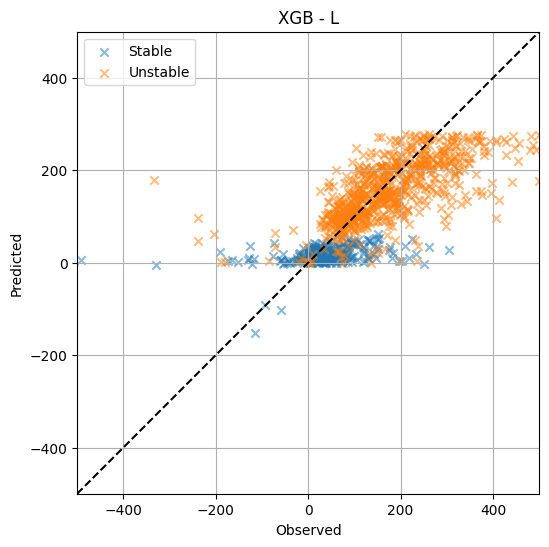

Saved: outputs/combined_plots/XGB_L.svg
Plotting: XGB TAU


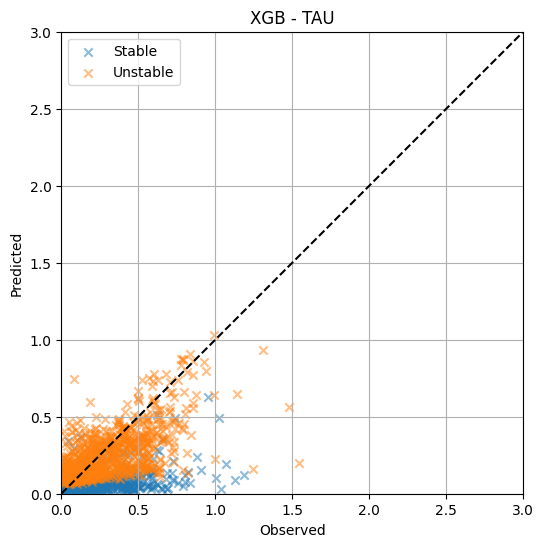

Saved: outputs/combined_plots/XGB_TAU.svg
Plotting: RF H


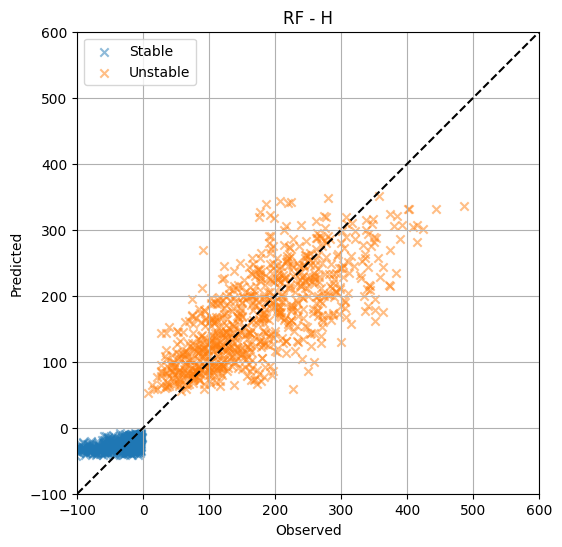

Saved: outputs/combined_plots/RF_H.svg
Plotting: ANN H


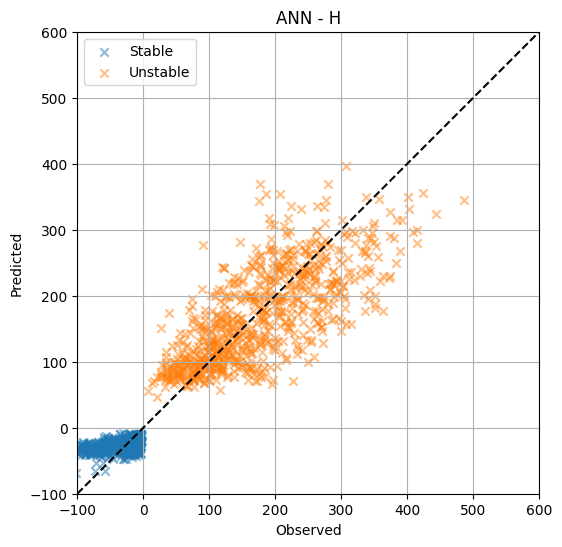

Saved: outputs/combined_plots/ANN_H.svg
Plotting: ANN TAU


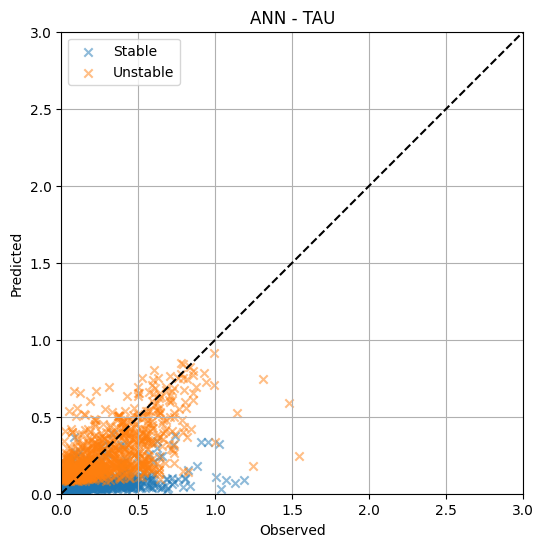

Saved: outputs/combined_plots/ANN_TAU.svg
Plotting: RF TAU


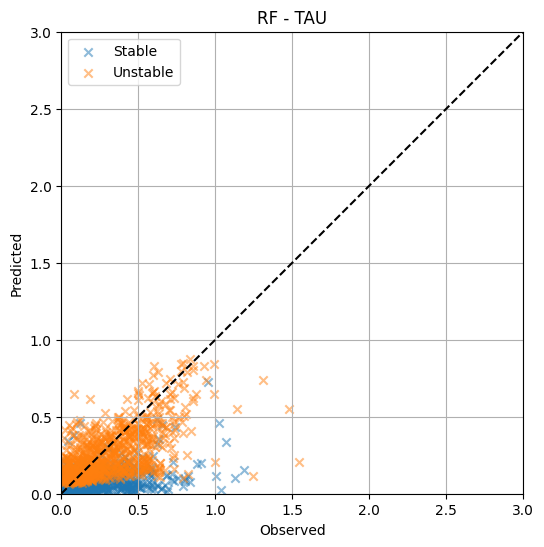

Saved: outputs/combined_plots/RF_TAU.svg
Plotting: XGB H


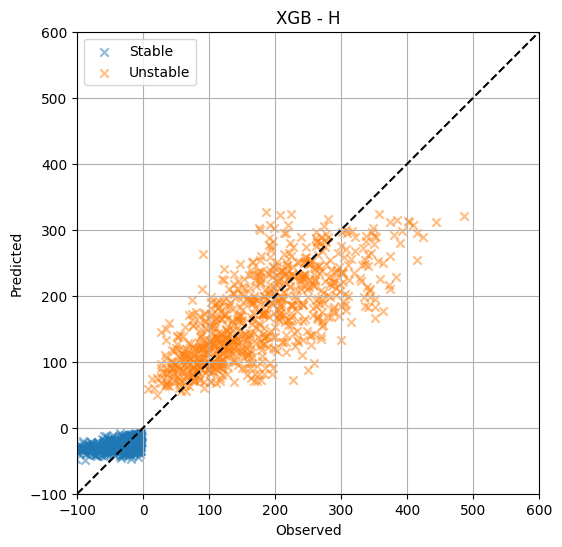

Saved: outputs/combined_plots/XGB_H.svg
Plotting: ANN L


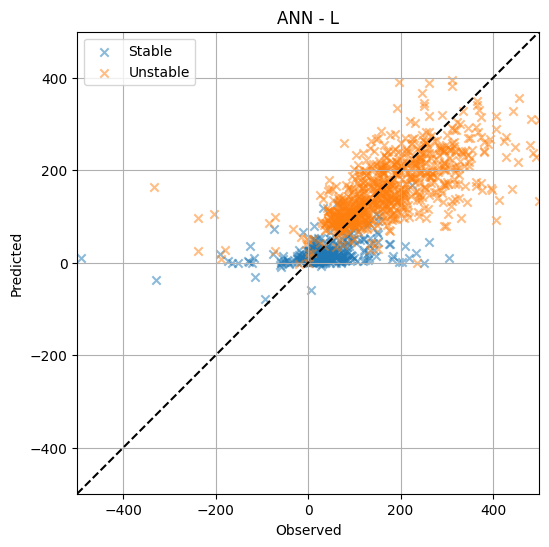

Saved: outputs/combined_plots/ANN_L.svg


In [8]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

base_path = "outputs/ensemble_preds/Ensemble1"
files = glob.glob(f"{base_path}/*.csv")

# -------- Group files --------
groups = {}

for f in files:
    name = os.path.basename(f).replace(".csv", "")
    model, target, stability = name.split("_")

    key = (model, target)

    if key not in groups:
        groups[key] = {}

    groups[key][stability] = f

# -------- Compute global ranges --------
H_vals, TAU_vals,L_vals = [], [],[]

for f in files:
    df = pd.read_csv(f)
    y_true = df["y_true"].values
    y_pred = df["y_pred"].values

    if "_H_" in f:
        H_vals.extend(y_true)
        H_vals.extend(y_pred)
    elif "TAU":
        TAU_vals.extend(y_true)
        TAU_vals.extend(y_pred)
    else:
        L_vals.extend(y_true)
        L_vals.extend(y_pred)

H_min, H_max = -100,600
TAU_min, TAU_max = 0,3
L_min,L_max=-500,500

# -------- Plot --------
save_dir = "outputs/combined_plots"
os.makedirs(save_dir, exist_ok=True)

for (model, target), data in groups.items():

    print(f"Plotting: {model} {target}")

    plt.figure(figsize=(6,6))

    # -------- Stable --------
    if "stable" in data:
        df = pd.read_csv(data["stable"])
        plt.scatter(
            df["y_true"], df["y_pred"],
            alpha=0.5, label="Stable", marker="x"
        )

    # -------- Unstable --------
    if "unstable" in data:
        df = pd.read_csv(data["unstable"])
        plt.scatter(
            df["y_true"], df["y_pred"],
            alpha=0.5, label="Unstable", marker="x"
        )

    # -------- Axis range --------
    if target == "H":
        vmin, vmax = H_min, H_max
    elif target =="TAU":
        vmin, vmax = TAU_min, TAU_max
    else:
        vmin, vmax = L_min,L_max

    plt.xlim(vmin, vmax)
    plt.ylim(vmin, vmax)

    # 1:1 line
    plt.plot([vmin, vmax], [vmin, vmax], "k--")

    plt.xlabel("Observed")
    plt.ylabel("Predicted")
    plt.title(f"{model} - {target}")
    plt.legend()
    plt.grid(True)
    plt.gca().set_aspect('equal', adjustable='box')

    path = f"{save_dir}/{model}_{target}.svg"
    plt.savefig(path)
    plt.show()

    print(f"Saved: {path}")


In [9]:

import pandas as pd
import numpy as np
import glob
import os
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

base_path = "outputs/ensemble_preds/Ensemble1"
files = glob.glob(f"{base_path}/*.csv")

# -------- Group by (model, target) --------
groups = {}

for f in files:
    name = os.path.basename(f).replace(".csv", "")
    model, target, stability = name.split("_")

    key = (model, target)

    if key not in groups:
        groups[key] = []

    groups[key].append(f)

# -------- Compute combined metrics --------
rows_H = []
rows_TAU = []
rows_L = []
for (model, target), flist in groups.items():

    y_true_all = []
    y_pred_all = []

    for f in flist:
        df = pd.read_csv(f)

        y_true_all.extend(df["y_true"].values)
        y_pred_all.extend(df["y_pred"].values)
        print(model, target)
        print(len(y_pred_all))
        print(len(y_true_all))

    y_true = np.array(y_true_all)
    y_pred = np.array(y_pred_all)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    N = len(y_true)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1]

    row = {
        "Model": model,
        "N": N,
        "RMSE": round(rmse, 3),
        "MAE": round(mae, 3),
        "R2": round(r2, 3),
        "CORR": round(corr, 3)
    }

    if target == "H":
        rows_H.append(row)
    elif target == "TAU":
        rows_TAU.append(row)
    else:
        rows_L.append(row)
    
    
df_H = pd.DataFrame(rows_H).sort_values("Model")
df_TAU = pd.DataFrame(rows_TAU).sort_values("Model")
df_L = pd.DataFrame(rows_L).sort_values("Model")

print("H Table")
# display(df_H.sort_values(["Model", "Regime"]))
print(df_H)
print("\nTAU Table")
print(df_TAU)
print("\n L Table")
print(df_L)



RF L
476
476
RF L
1188
1188
XGB L
476
476
XGB L
1188
1188
XGB TAU
808
808
XGB TAU
2045
2045
RF H
746
746
RF H
1241
1241
ANN H
495
495
ANN H
1241
1241
ANN TAU
1237
1237
ANN TAU
2045
2045
RF TAU
808
808
RF TAU
2045
2045
XGB H
746
746
XGB H
1241
1241
ANN L
476
476
ANN L
1188
1188
H Table
  Model     N    RMSE     MAE     R2   CORR
1   ANN  1241  50.529  36.922  0.835  0.914
0    RF  1241  50.087  36.594  0.838  0.916
2   XGB  1241  49.927  36.469  0.839  0.917

TAU Table
  Model     N   RMSE    MAE     R2   CORR
1   ANN  2045  0.180  0.110  0.336  0.631
2    RF  2045  0.178  0.109  0.350  0.644
0   XGB  2045  0.179  0.110  0.346  0.644

 L Table
  Model     N    RMSE     MAE     R2   CORR
2   ANN  1188  72.780  47.857  0.600  0.782
0    RF  1188  71.673  46.867  0.612  0.791
1   XGB  1188  72.933  47.965  0.598  0.787


In [ ]:

import matplotlib.pyplot as plt

save_dir = "outputs/final_combined"
os.makedirs(save_dir, exist_ok=True)

# Group files
groups = {}
for f in files:
    name = os.path.basename(f).replace(".csv", "")
    model, target, stability = name.split("_")
    key = (model, target)

    if key not in groups:
        groups[key] = {}

    groups[key][stability] = f

# Global ranges
H_vals, TAU_vals = [], []

for f in files:
    df = pd.read_csv(f)
    if "_H_" in f:
        H_vals.extend(df["y_true"])
        H_vals.extend(df["y_pred"])
    else:
        TAU_vals.extend(df["y_true"])
        TAU_vals.extend(df["y_pred"])

H_min, H_max = min(H_vals), max(H_vals)
TAU_min, TAU_max = min(TAU_vals), max(TAU_vals)


def get_metrics(df):
    y_true = df["y_true"].values
    y_pred = df["y_pred"].values

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    return [
        len(y_true),
        round(np.sqrt(mean_squared_error(y_true, y_pred)), 3),
        round(mean_absolute_error(y_true, y_pred), 3),
        round(r2_score(y_true, y_pred), 3),
        round(np.corrcoef(y_true, y_pred)[0, 1], 3)
    ]


for (model, target), data in groups.items():

    plt.figure(figsize=(7,7))

    # Plot points
    if "stable" in data:
        df_s = pd.read_csv(data["stable"])
        plt.scatter(df_s["y_true"], df_s["y_pred"], alpha=0.5, label="Stable")

    if "unstable" in data:
        df_u = pd.read_csv(data["unstable"])
        plt.scatter(df_u["y_true"], df_u["y_pred"], alpha=0.5, label="Unstable")

    # Axis range
    if target == "H":
        vmin, vmax = H_min, H_max
    else:
        vmin, vmax = TAU_min, TAU_max

    plt.xlim(vmin, vmax)
    plt.ylim(vmin, vmax)

    plt.plot([vmin, vmax], [vmin, vmax], "k--")

    plt.xlabel("Observed")
    plt.ylabel("Predicted")
    plt.title(f"{model} - {target}")
    plt.legend()
    plt.grid(True)
    plt.gca().set_aspect('equal', adjustable='box')

    # -------- Metrics Table --------
    cell_text = []

    if "stable" in data:
        cell_text.append(["Stable"] + get_metrics(df_s))

    if "unstable" in data:
        cell_text.append(["Unstable"] + get_metrics(df_u))

    col_labels = ["Regime", "N", "RMSE", "MAE", "R2", "CORR"]

    table = plt.table(
        cellText=cell_text,
        colLabels=col_labels,
        loc="lower right",
        cellLoc="center"
    )

    table.scale(1, 1.2)

    path = f"{save_dir}/{model}_{target}.svg"
    plt.savefig(path)
    plt.show()

    print("Saved:", path)
